## EDA

### Load Dataset

import pandas as pd

df = pd.read_csv("../data/processed/cuad_risk_dataset.csv")

print(df.shape)
df.head()


### Checking Risk Balance

In [2]:
df["risk_level"].value_counts()


risk_level
Low       2174
Medium    1511
High      1502
Name: count, dtype: int64

#### Dataset is fairly balanced across classes

 Low risk slightly higher (2174 samples)

 Medium and  High are almost equal (~1500 each)

 No severe class imbalance → good for BERT training

 Hence, model won’t be biased toward one risk type

### Plotting Class Distribution

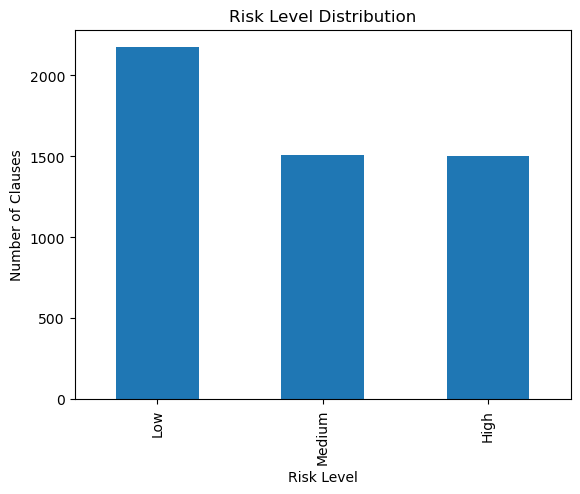

In [5]:
import matplotlib.pyplot as plt

df["risk_level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Clauses")
plt.show()


### Clause Length

In [6]:
df["text_length"] = df["clause_text"].apply(lambda x: len(x.split()))

df["text_length"].describe()


count    5225.000000
mean       50.241722
std        41.763545
min         1.000000
25%        25.000000
50%        40.000000
75%        63.000000
max       479.000000
Name: text_length, dtype: float64

#### Clause Length Statistics — Insights

- Average clause length ≈ 50 words

- Most clauses fall between 25–63 words (middle 50%)

- Some very long clauses exist (up to 479 words)

   Distribution is right-skewed (few long legal paragraphs)

Conclusion:
- BERT can easily handle typical clauses; we may cap max length later (e.g., 128–256 tokens).

### Clause Length Distribution

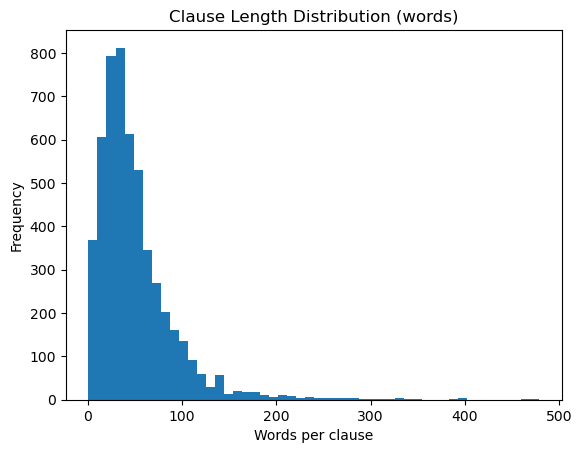

In [8]:
plt.hist(df["text_length"], bins=50)
plt.title("Clause Length Distribution (words)")
plt.xlabel("Words per clause")
plt.ylabel("Frequency")
plt.show()


- Majority of clauses are short to medium length
- Very long clauses are rare (outliers)
- No extreme noise or broken text

### Comparing Lengths by risk level

In [9]:
df.groupby("risk_level")["text_length"].mean()


risk_level
High      58.466711
Low       38.393744
Medium    58.646592
Name: text_length, dtype: float64

### Most Common Words 

In [11]:
from collections import Counter
import re

words = " ".join(df["clause_text"].tolist()).lower()
words = re.findall(r"\b[a-z]+\b", words)

common_words = Counter(words).most_common(40)
common_words


[('the', 18432),
 ('of', 12311),
 ('to', 9725),
 ('and', 8372),
 ('or', 7390),
 ('in', 5700),
 ('agreement', 4491),
 ('any', 4210),
 ('this', 4164),
 ('shall', 3797),
 ('a', 3336),
 ('for', 3223),
 ('be', 2665),
 ('by', 2648),
 ('party', 2614),
 ('with', 2387),
 ('such', 2101),
 ('other', 1863),
 ('as', 1842),
 ('s', 1714),
 ('that', 1692),
 ('term', 1668),
 ('not', 1582),
 ('its', 1512),
 ('on', 1208),
 ('all', 1139),
 ('will', 1137),
 ('date', 1071),
 ('under', 1065),
 ('may', 1048),
 ('is', 1042),
 ('at', 1035),
 ('company', 1030),
 ('written', 979),
 ('section', 970),
 ('without', 951),
 ('prior', 842),
 ('right', 833),
 ('which', 821),
 ('provided', 821)]

- Legal language dominated by functional legal terms:

“shall”, “party”, “agreement”, “term”, “section”

- Contract structure words appear frequently:

“written”, “prior”, “date”, “right”

- Stopwords are meaningful in legal context